# ====================================
# Paso 1 y Paso 2: ANÁLISIS Y PREPROCESADO
# ====================================


### 1. Importar librerías

In [ ]:
from google.colab import drive
import os
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

import zipfile
import cv2

import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler



---



### 2. Descarga de ejemplos

In [ ]:
# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Definir la ruta donde guardaste los archivos en tu Drive
# Cambia 'Mi unidad/Colab Notebooks/IA_Bus' por la ruta real en tu Drive
ruta_drive = '/content/drive/MyDrive/Colab Notebooks/iaic/labF/Datos/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).




---


### 3. Análisis del dataset TABULAR



--- 1. ANÁLISIS DEL DATASET TABULAR (Línea C1) ---

-> PROBLEMA A RESOLVER:
Clasificación Multiclase. El objetivo es predecir la variable categórica 'Aforo'.

-> ATRIBUTOS DEL DATASET (¿Cuántos hay? ¿De qué tipo?):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Fecha            403 non-null    datetime64[ns]
 1   Longitud         404 non-null    float64       
 2   Latitud          404 non-null    float64       
 3   Temperatura      404 non-null    float64       
 4   Humedad          404 non-null    float64       
 5   eCo2             404 non-null    int64         
 6   Aforo            404 non-null    object        
 7   Redes            404 non-null    int64         
 8   Señal Detectada  404 non-null    int64         
 9   Hora             403 non-null    float64       
 10  Minuto           403 non-null    float6

/tmp/ipykernel_4255/177453694.py:37: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df_bus[vars_numericas].hist(ax=ax, bins=30, color='royalblue', edgecolor='black')


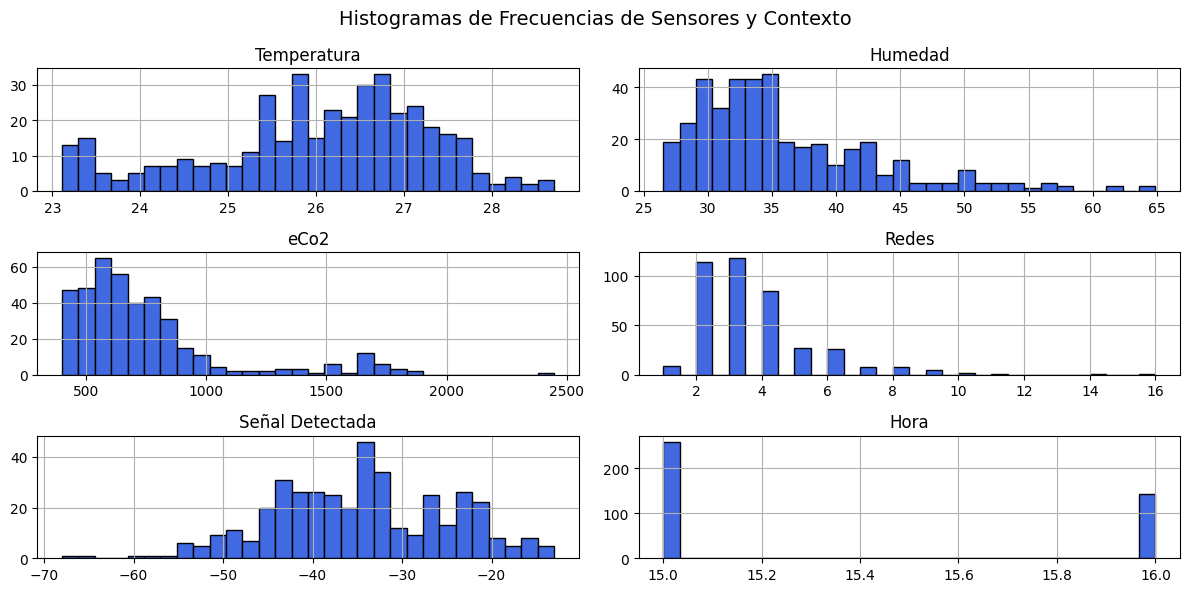


-> RELACIÓN ENTRE ATRIBUTOS (Matriz de Correlación - corr)...


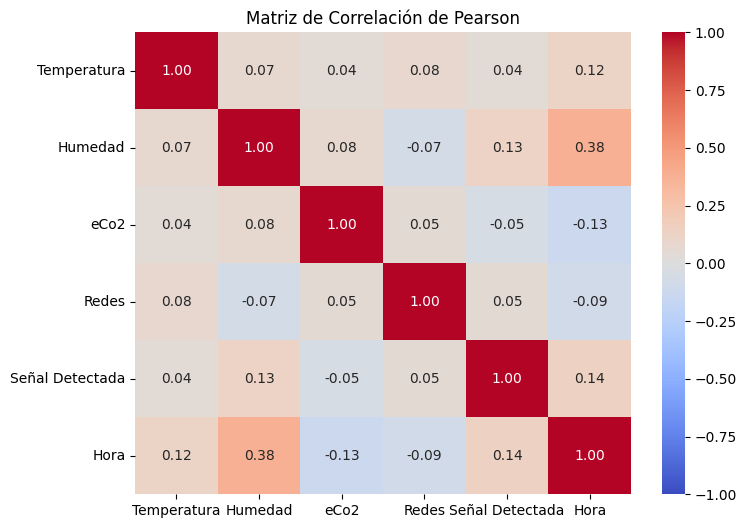


-> RELACIÓN CRUZADA Y SEPARACIÓN DE CLASES (pairplot)...


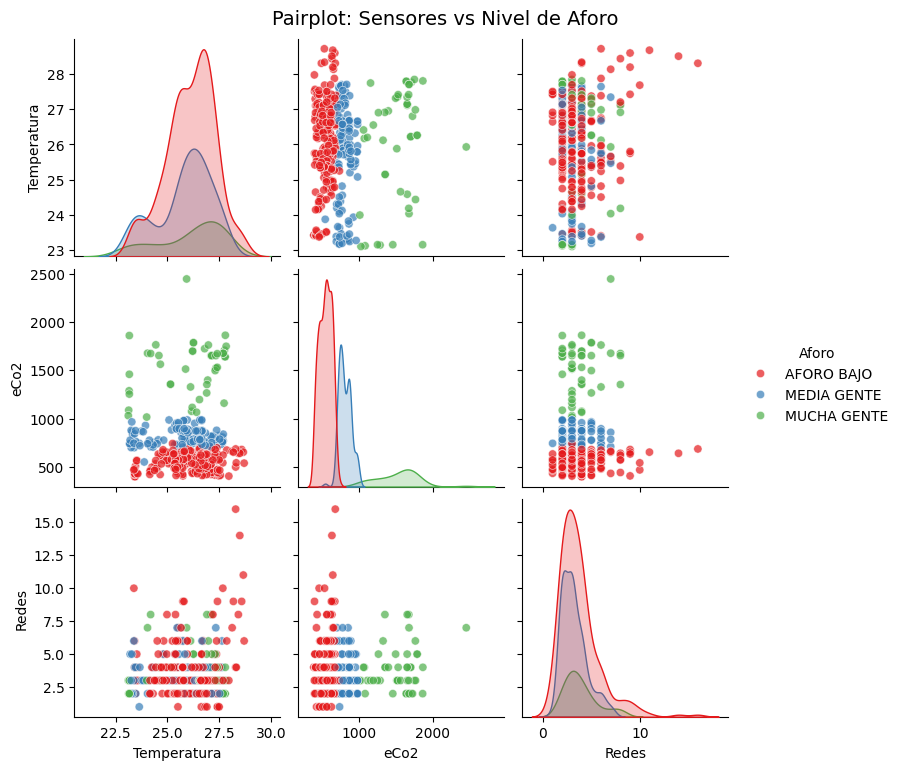

In [ ]:
print("======================================================")
print("--- 1. ANÁLISIS DEL DATASET TABULAR (Línea C1) ---")
print("======================================================\n")

# Ruta exacta proporcionada
ruta_tabular = "/content/drive/MyDrive/Colab Notebooks/iaic/labF/Datos/LineaC1.csv"

# 1. Determinar el problema a resolver
print("-> PROBLEMA A RESOLVER:")
print("Clasificación Multiclase. El objetivo es predecir la variable categórica 'Aforo'.\n")

# Cargar el dataset (usando latin1 para leer las 'ñ' en 'Señal Detectada')
df_bus = pd.read_csv(ruta_tabular, encoding='latin1')

# Convertir Fecha a datetime para extraer variables numéricas si es necesario
# df_bus['Fecha'] = pd.to_datetime(df_bus['Fecha'])
df_bus['Fecha'] = pd.to_datetime(df_bus['Fecha'], errors='coerce')
df_bus['Hora'] = df_bus['Fecha'].dt.hour
df_bus['Minuto'] = df_bus['Fecha'].dt.minute

# 2. Describir los atributos del dataset
print("-> ATRIBUTOS DEL DATASET (¿Cuántos hay? ¿De qué tipo?):")
df_bus.info()
print("\n")

print("-> ESTADÍSTICOS DESCRIPTIVOS (describe):")
# Filtramos solo las columnas numéricas para el análisis matemático
vars_numericas = ['Temperatura', 'Humedad', 'eCo2', 'Redes', 'Señal Detectada', 'Hora']
print(df_bus[vars_numericas].describe().round(2))
print("\n")

# 3. Dibujar histogramas de frecuencias (hist de matplotlib)
print("-> GENERANDO HISTOGRAMAS DE FRECUENCIAS (hist)...")
plt.style.use('default')
fig = plt.figure(figsize=(12, 6))
ax = fig.gca()
df_bus[vars_numericas].hist(ax=ax, bins=30, color='royalblue', edgecolor='black')
plt.suptitle('Histogramas de Frecuencias de Sensores y Contexto', fontsize=14)
plt.tight_layout()
plt.show()

# 4. Describir relación entre los atributos (corr)
print("\n-> RELACIÓN ENTRE ATRIBUTOS (Matriz de Correlación - corr)...")
correlacion = df_bus[vars_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Matriz de Correlación de Pearson")
plt.show()

# 5. Pairplot de seaborn
print("\n-> RELACIÓN CRUZADA Y SEPARACIÓN DE CLASES (pairplot)...")
# Usamos el 'Aforo' como color (hue) para ver si las variables numéricas separan bien las clases
vars_pairplot = ['Temperatura', 'eCo2', 'Redes', 'Aforo']
sns.pairplot(df_bus[vars_pairplot], hue='Aforo', palette='Set1', plot_kws={'alpha': 0.7})
plt.suptitle('Pairplot: Sensores vs Nivel de Aforo', y=1.02, fontsize=14)
plt.show()

---


### 4. Análisis del dataset IMÁGENES


--- 2. ANÁLISIS DEL DATASET DE IMÁGENES (YOLOv8) ---

-> PROBLEMA A RESOLVER (Original): Detección de Objetos (Bounding Boxes).
-> PROBLEMA A RESOLVER (Adaptado al Negocio): Regresión/Clasificación (Conteo de personas por frame).

Extrayendo dataset de imágenes...
Analizando resolución, brillo y conteo de personas en las imágenes...

-> ATRIBUTOS EXTRAÍDOS DE LAS IMÁGENES:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1144 entries, 0 to 1143
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   archivo           1144 non-null   object 
 1   num_personas      1144 non-null   int64  
 2   brillo_medio      1144 non-null   float64
 3   resolucion_total  1144 non-null   int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 35.9+ KB


-> ESTADÍSTICOS DESCRIPTIVOS DE IMÁGENES (describe):
       num_personas  brillo_medio  resolucion_total
count       1144.00       1144.00            1144.0
mean          

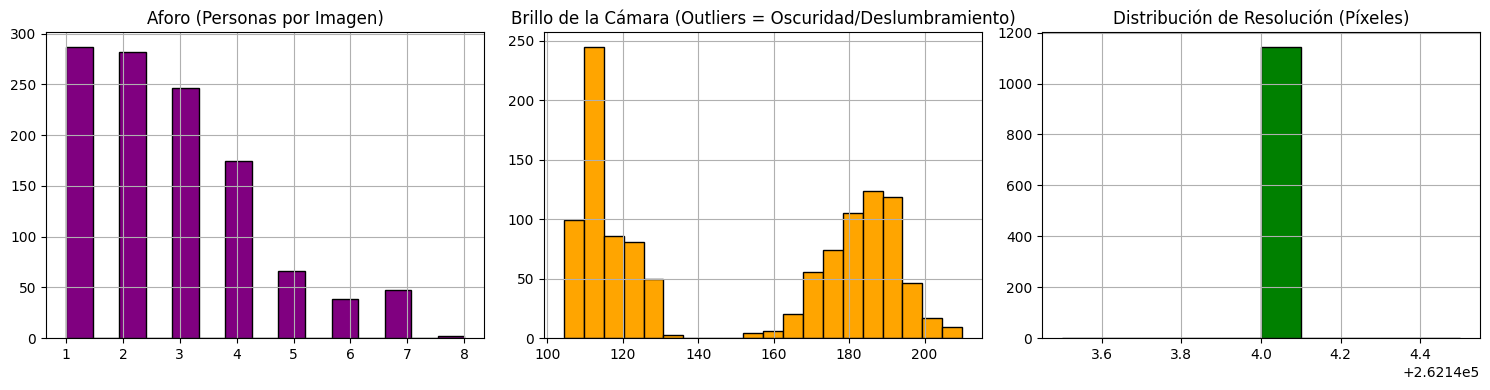


-> RELACIÓN ENTRE METADATOS DE IMÁGENES (corr)...
                  num_personas  brillo_medio  resolucion_total
num_personas             1.000        -0.438               NaN
brillo_medio            -0.438         1.000               NaN
resolucion_total           NaN           NaN               NaN


In [ ]:
print("======================================================")
print("--- 2. ANÁLISIS DEL DATASET DE IMÁGENES (YOLOv8) ---")
print("======================================================\n")

# Ruta exacta proporcionada
ruta_zip = "/content/drive/MyDrive/Colab Notebooks/iaic/labF/Datos/personas_en_autobus_tesis.v2i.yolov8.zip"
directorio_extraccion = "/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/dataset_imagenes_yolo"

# 1. Determinar el problema a resolver
print("-> PROBLEMA A RESOLVER (Original): Detección de Objetos (Bounding Boxes).")
print("-> PROBLEMA A RESOLVER (Adaptado al Negocio): Regresión/Clasificación (Conteo de personas por frame).\n")

# Extraer el ZIP si no se ha extraído antes
if not os.path.exists(directorio_extraccion):
    print("Extrayendo dataset de imágenes...")
    with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
        zip_ref.extractall(directorio_extraccion)

# 2. Explorar el dataset YOLO para extraer atributos (Metadatos)
# YOLO suele tener carpetas 'train/images' y 'train/labels'
datos_imagenes = []
print("Analizando resolución, brillo y conteo de personas en las imágenes...\n")

# Buscamos recursivamente todos los archivos .txt de etiquetas
for root, dirs, files in os.walk(directorio_extraccion):
    for file in files:
        if file.endswith(".txt") and file != "classes.txt":
            ruta_txt = os.path.join(root, file)
            # La imagen correspondiente suele estar en una carpeta paralela 'images'
            ruta_img = ruta_txt.replace('/labels', '/images').replace('.txt', '.jpg')

            # Si la imagen es .png, la cambiamos
            if not os.path.exists(ruta_img):
                ruta_img = ruta_img.replace('.jpg', '.png')

            # Contar personas (número de líneas en el archivo txt = número de bounding boxes)
            try:
                with open(ruta_txt, 'r') as f:
                    lineas = f.readlines()
                    num_personas = len(lineas)

                # Leer propiedades de la imagen
                if os.path.exists(ruta_img):
                    img = cv2.imread(ruta_img)
                    if img is not None:
                        alto, ancho = img.shape[:2]
                        # Brillo medio en escala de grises
                        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                        brillo = gray.mean()

                        datos_imagenes.append({
                            'archivo': os.path.basename(ruta_img),
                            'num_personas': num_personas,
                            'brillo_medio': brillo,
                            'resolucion_total': alto * ancho
                        })
            except Exception as e:
                pass

# Convertimos la información de las imágenes a un DataFrame
df_imagenes = pd.DataFrame(datos_imagenes)

# 3. Describir los atributos del dataset
print("-> ATRIBUTOS EXTRAÍDOS DE LAS IMÁGENES:")
df_imagenes.info()
print("\n")

print("-> ESTADÍSTICOS DESCRIPTIVOS DE IMÁGENES (describe):")
print(df_imagenes[['num_personas', 'brillo_medio', 'resolucion_total']].describe().round(2))
print("\n")

# 4. Dibujar histogramas de frecuencias (hist)
print("-> GENERANDO HISTOGRAMAS DE FRECUENCIAS DE IMÁGENES...")
plt.style.use('default')
fig = plt.figure(figsize=(15, 4))

ax1 = fig.add_subplot(131)
df_imagenes['num_personas'].hist(ax=ax1, bins=15, color='purple', edgecolor='black')
ax1.set_title('Aforo (Personas por Imagen)')

ax2 = fig.add_subplot(132)
df_imagenes['brillo_medio'].hist(ax=ax2, bins=20, color='orange', edgecolor='black')
ax2.set_title('Brillo de la Cámara (Outliers = Oscuridad/Deslumbramiento)')

ax3 = fig.add_subplot(133)
df_imagenes['resolucion_total'].hist(ax=ax3, bins=10, color='green', edgecolor='black')
ax3.set_title('Distribución de Resolución (Píxeles)')

plt.tight_layout()
plt.show()

# 5. Relación entre atributos de imágenes (corr)
print("\n-> RELACIÓN ENTRE METADATOS DE IMÁGENES (corr)...")
correlacion_img = df_imagenes[['num_personas', 'brillo_medio', 'resolucion_total']].corr()
print(correlacion_img.round(3))

**¿Qué valor aporta esto al informe final?**
* **En el Tabular (pairplot y corr)**: El Pairplot te dirá de inmediato si la variable eCo2 es capaz, por sí sola, de diferenciar los colores del Aforo. Si ves agrupaciones claras, tu IA tabular funcionará de maravilla.

* **En las Imágenes (hist del YOLOv8)**: El describe() sobre num_personas te revelará la media real de pasajeros en el dataset de la "tesis". Así sabrás si el modelo está aprendiendo de autobuses mayormente vacíos, o si hay un buen balance de autobuses llenos.

---


### 5. Preprocesamiento dataset TABULAR


--- PREPARACIÓN Y ANÁLISIS DE ESCALADO ---
--- DATASET TABULAR (LineaC1) ---

Instancias iniciales: 404
-> Nulos eliminados: 0
-> Se han detectado y eliminado 1 filas con fechas corruptas.
-> Outliers de eCo2 truncados a: 1786.5600000000004 ppm

--- INCISO: COMPARATIVA DE ESCALADO EN LA VARIABLE eCo2 ---


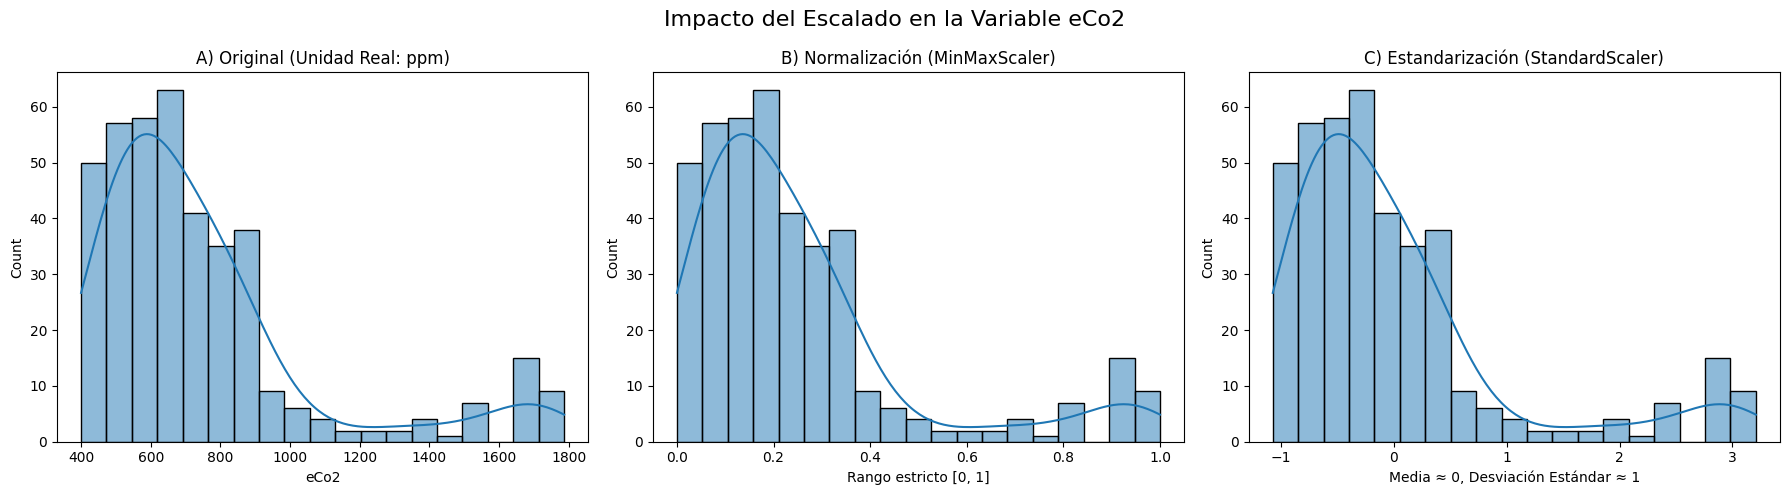

Demostración de la Teoría del Manual:
-> ORIGINAL:       Min = 400.00, Max = 1786.56, Media = 747.85
-> NORMALIZADO:    Min = 0.00, Max = 1.00, Media = 0.25
-> ESTANDARIZADO:  Min = -1.07, Max = 3.21, Media = 0.00 (Cercana a 0)

✅ Mapeo exitoso: 0 nulos generados.
-> Variable 'Aforo' convertida a numérica ordinal (0, 1, 2).

✅ Dataset Tabular Completamente Procesado. Muestra final:


,Temperatura,Humedad,eCo2,Redes,Señal Detectada,Hora,TARGET_Aforo
0,-2.054896,-0.335269,-1.074063,0.227458,-0.835720,-0.74162,0
1,-2.046997,-0.394948,-1.074063,0.227458,-0.733784,-0.74162,0
2,-2.046997,-0.456048,-1.074063,0.227458,-0.529913,-0.74162,0
3,-2.046997,-0.477362,-1.012309,-0.308598,-1.855075,-0.74162,0
4,-2.039099,-0.481625,-0.996871,-0.308598,0.693313,-0.74162,0


In [ ]:
print("======================================================")
print("--- PREPARACIÓN Y ANÁLISIS DE ESCALADO ---")
print("--- DATASET TABULAR (LineaC1) ---")
print("======================================================\n")

# 1. Cargar el dataset
ruta_tabular = "/content/drive/MyDrive/Colab Notebooks/iaic/labF/Datos/LineaC1.csv"
df_bus = pd.read_csv(ruta_tabular, encoding='latin1')
print(f"Instancias iniciales: {df_bus.shape[0]}")

# 2. "Borrar filas con valores nulos"
nulos_antes = df_bus.isnull().sum().sum()
df_bus = df_bus.dropna()
print(f"-> Nulos eliminados: {nulos_antes}")

# 3. Tratamiento de Fechas y extracción de 'Hora'
# a. Forzamos la conversión (valores mal escritos serán NaT)
df_bus['Fecha'] = pd.to_datetime(df_bus['Fecha'], errors='coerce')
errores = df_bus['Fecha'].isna().sum()
if errores > 0:
    print(f"-> Se han detectado y eliminado {errores} filas con fechas corruptas.")
# b. Eliminamos NaT y extraemos la hora
df_bus = df_bus.dropna(subset=['Fecha'])
df_bus['Hora'] = df_bus['Fecha'].dt.hour

# 4. "El valor de un atributo categórico está mal escrito"
df_bus['Aforo'] = df_bus['Aforo'].astype(str).str.strip().str.upper()

# 5. "Un atributo toma siempre el mismo valor" (Constantes)
columnas_constantes = [col for col in df_bus.columns if df_bus[col].nunique() == 1]
if columnas_constantes:
    df_bus = df_bus.drop(columns=columnas_constantes)
    print(f"-> Atributos constantes eliminados: {columnas_constantes}")

# 6. "Hay valores extremos para un atributo" (Outliers)
p99_eco2 = df_bus['eCo2'].quantile(0.99)
df_bus['eCo2'] = np.clip(df_bus['eCo2'], a_min=0, a_max=p99_eco2)
print(f"-> Outliers de eCo2 truncados a: {p99_eco2} ppm")


# =====================================================================
# --- INCISO VISUAL: GRAFICANDO NORMALIZACIÓN VS ESTANDARIZACIÓN ---
# =====================================================================
print("\n--- INCISO: COMPARATIVA DE ESCALADO EN LA VARIABLE eCo2 ---")
variable = df_bus[['eCo2']]

# Aplicamos las dos transformaciones solo para la demo gráfica
scaler_std_demo = StandardScaler()
variable_std = scaler_std_demo.fit_transform(variable)

scaler_minmax_demo = MinMaxScaler()
variable_minmax = scaler_minmax_demo.fit_transform(variable)

# Graficar
plt.style.use('default')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(variable, kde=True, color='gray', ax=axes[0], legend=False)
axes[0].set_title('A) Original (Unidad Real: ppm)')
axes[0].set_xlabel('eCo2')

sns.histplot(variable_minmax, kde=True, color='green', ax=axes[1], legend=False)
axes[1].set_title('B) Normalización (MinMaxScaler)')
axes[1].set_xlabel('Rango estricto [0, 1]')

sns.histplot(variable_std, kde=True, color='blue', ax=axes[2], legend=False)
axes[2].set_title('C) Estandarización (StandardScaler)')
axes[2].set_xlabel('Media ≈ 0, Desviación Estándar ≈ 1')

plt.suptitle("Impacto del Escalado en la Variable eCo2", fontsize=16)
plt.tight_layout()
plt.show()

# Demostración numérica de la teoría de tu manual
print("Demostración de la Teoría del Manual:")
print(f"-> ORIGINAL:       Min = {variable.min().values[0]:.2f}, Max = {variable.max().values[0]:.2f}, Media = {variable.mean().values[0]:.2f}")
print(f"-> NORMALIZADO:    Min = {variable_minmax.min():.2f}, Max = {variable_minmax.max():.2f}, Media = {variable_minmax.mean():.2f}")
print(f"-> ESTANDARIZADO:  Min = {variable_std.min():.2f}, Max = {variable_std.max():.2f}, Media = {variable_std.mean():.2f} (Cercana a 0)\n")
# =====================================================================


# 7. "Determinar si se puede eliminar algún atributo (correlación muy fuerte)"
corr_matrix = df_bus[['Temperatura', 'Humedad', 'eCo2', 'Redes', 'Señal Detectada']].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
cols_to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.90)]
if cols_to_drop:
    df_bus = df_bus.drop(columns=cols_to_drop)
    print(f"-> Atributos eliminados por altísima correlación: {cols_to_drop}")

# 8. "Convertir atributos categóricos a numéricos"
mapeo_ordinal = {'AFORO BAJO': 0, 'MEDIA GENTE': 1, 'MUCHA GENTE': 2}
df_bus['Aforo_encoded'] = df_bus['Aforo'].map(mapeo_ordinal)
# Validamos que el mapeo fue 100% exitoso (Programación Defensiva)
nans_detectados = df_bus['Aforo_encoded'].isna().sum()
if nans_detectados > 0:
    print(f"⚠️ Atención: Se han detectado {nans_detectados} filas con categorías desconocidas.")
    df_bus = df_bus.dropna(subset=['Aforo_encoded'])
else:
    print("✅ Mapeo exitoso: 0 nulos generados.")
# Forzamos que sea tipo entero para Scikit-Learn
df_bus['Aforo_encoded'] = df_bus['Aforo_encoded'].astype(int)
print("-> Variable 'Aforo' convertida a numérica ordinal (0, 1, 2).")

# 9. "Realizar estandarización (StandardScaler)" FINAL DE TODO EL DATASET
features_numericas = ['Temperatura', 'Humedad', 'eCo2', 'Redes', 'Señal Detectada', 'Hora']
# Filtramos asegurando que solo usamos las variables que sobrevivieron a la limpieza
features_finales = [f for f in features_numericas if f in df_bus.columns]

# IMPORTANTE: Reseteamos el índice de df_bus para que coincida con la matriz del escalador
df_bus_limpio = df_bus.dropna(subset=['Aforo_encoded']).reset_index(drop=True)

X_tabular = df_bus[features_finales]
y_tabular = df_bus['Aforo_encoded']

# Escalamos todas las columnas finales a la vez
scaler_final = StandardScaler()
X_tabular_scaled = scaler_final.fit_transform(X_tabular)

# Reconstruimos el DataFrame para visualizar el resultado final listo para IA
df_tabular_listo = pd.DataFrame(X_tabular_scaled, columns=features_finales)
df_tabular_listo['TARGET_Aforo'] = y_tabular.values

print("\n✅ Dataset Tabular Completamente Procesado. Muestra final:")
display(df_tabular_listo.head())



---


### 6. Guardar el dataset TABULAR

In [ ]:
# Guardar en tu Drive (asegúrate de tenerlo montado)
ruta_salida = '/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/LineaC1_Limpio.csv'

# index=False evita que se cree una columna extra de números innecesaria
df_tabular_listo.to_csv(ruta_salida, index=False)

print(f"✅ Dataset guardado con éxito en: {ruta_salida}")

✅ Dataset guardado con éxito en: /content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/LineaC1_Limpio.csv



---


### 7. Preprocesamiento del dataset IMAGEN

--- PREPARACIÓN Y ANÁLISIS DE ESCALADO: IMÁGENES (YOLOv8) ---

1. Extrayendo metadatos y limpiando anomalías...
-> Anomalías (archivos huérfanos/rotos) eliminadas: 2
-> Aforo continuo convertido a categórico (0, 1, 2). Límites: Bajo<=2, Medio<=3, Alto>3

--- INCISO VISUAL: ¿POR QUÉ NORMALIZAMOS LAS IMÁGENES? ---


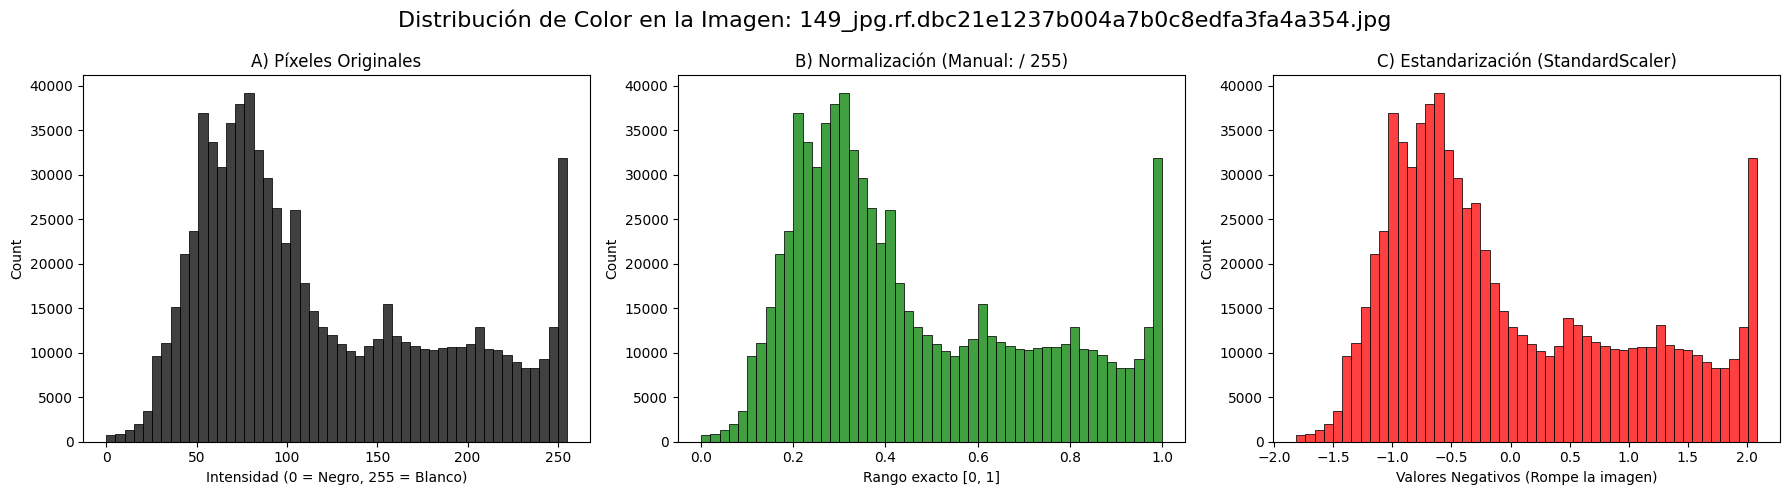

Demostración de la Teoría del Manual para Visión Artificial:
-> ORIGINAL:    Rango de 0 a 255
-> NORMALIZADO: Rango de 0.00 a 1.00 (Ideal para Redes Neuronales)
-> ESTANDARIZADO: Rango de -1.81 a 2.08 (Inviable: no existen colores negativos)

-> Función 'cargar_y_normalizar_imagen' definida correctamente.
✅ Dataset de Imágenes Listo. Muestra de los metadatos:


,ruta_imagen,personas_detectadas,TARGET_Aforo_Visual
0,/content/drive/MyDrive/Colab Notebooks/iaic/la...,4,2
1,/content/drive/MyDrive/Colab Notebooks/iaic/la...,4,2
2,/content/drive/MyDrive/Colab Notebooks/iaic/la...,4,2
3,/content/drive/MyDrive/Colab Notebooks/iaic/la...,3,1
4,/content/drive/MyDrive/Colab Notebooks/iaic/la...,2,0


In [ ]:
print("======================================================")
print("--- PREPARACIÓN Y ANÁLISIS DE ESCALADO: IMÁGENES (YOLOv8) ---")
print("======================================================\n")

directorio_extraccion = "/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/dataset_imagenes_yolo"
datos_limpios_imagenes = []
anomalias_eliminadas = 0

# 1. Reconstruimos el dataset de metadatos
print("1. Extrayendo metadatos y limpiando anomalías...")
for root, dirs, files in os.walk(directorio_extraccion):
    for file in files:
        if file.endswith(".txt") and file != "classes.txt":
            ruta_txt = os.path.join(root, file)
            ruta_img = ruta_txt.replace('/labels', '/images').replace('.txt', '.jpg')

            # Si no es .jpg, probamos .png
            if not os.path.exists(ruta_img):
                ruta_img = ruta_img.replace('.jpg', '.png')

            # Regla: "Falta el valor de un atributo" (Si no existe la imagen para el .txt, es anomalía)
            if not os.path.exists(ruta_img):
                anomalias_eliminadas += 1
                continue

            with open(ruta_txt, 'r') as f:
                num_personas = len(f.readlines())

            datos_limpios_imagenes.append({
                'ruta_imagen': ruta_img,
                'personas_detectadas': num_personas
            })

df_imagenes = pd.DataFrame(datos_limpios_imagenes)
print(f"-> Anomalías (archivos huérfanos/rotos) eliminadas: {anomalias_eliminadas}")

# 2. "Hay valores extremos para un atributo" (Outliers visuales)
p95_personas = df_imagenes['personas_detectadas'].quantile(0.95)
df_imagenes['personas_detectadas'] = np.clip(df_imagenes['personas_detectadas'], a_min=0, a_max=p95_personas)

# 3. "Convertir valor continuo en atributo categórico"
p33 = df_imagenes['personas_detectadas'].quantile(0.33)
p66 = df_imagenes['personas_detectadas'].quantile(0.66)

def categorizar_aforo_visual(num):
    if num <= p33: return 0
    elif num <= p66: return 1
    else: return 2

df_imagenes['TARGET_Aforo_Visual'] = df_imagenes['personas_detectadas'].apply(categorizar_aforo_visual)
print(f"-> Aforo continuo convertido a categórico (0, 1, 2). Límites: Bajo<={int(p33)}, Medio<={int(p66)}, Alto>{int(p66)}")


# =====================================================================
# --- INCISO VISUAL: GRAFICANDO NORMALIZACIÓN VS ESTANDARIZACIÓN ---
# =====================================================================
print("\n--- INCISO VISUAL: ¿POR QUÉ NORMALIZAMOS LAS IMÁGENES? ---")

if not df_imagenes.empty:
    # Tomamos la primera imagen válida de nuestro DataFrame limpio
    ruta_imagen_ejemplo = df_imagenes.iloc[0]['ruta_imagen']

    # Leer imagen y convertir a un array 1D de píxeles
    img = cv2.imread(ruta_imagen_ejemplo)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pixeles_originales = img_rgb.ravel() # Aplana la imagen a una lista de números

    # Aplicar Normalización (División por 255, equivalente a MinMaxScaler [0,1])
    pixeles_normalizados = pixeles_originales / 255.0

    # Aplicar Estandarización (StandardScaler)
    scaler_img = StandardScaler()
    pixeles_estandarizados = scaler_img.fit_transform(pixeles_originales.reshape(-1, 1)).ravel()

    # GRAFICAR LA COMPARATIVA
    plt.style.use('default')
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.histplot(pixeles_originales, bins=50, color='black', ax=axes[0])
    axes[0].set_title('A) Píxeles Originales')
    axes[0].set_xlabel('Intensidad (0 = Negro, 255 = Blanco)')

    sns.histplot(pixeles_normalizados, bins=50, color='green', ax=axes[1])
    axes[1].set_title('B) Normalización (Manual: / 255)')
    axes[1].set_xlabel('Rango exacto [0, 1]')

    sns.histplot(pixeles_estandarizados, bins=50, color='red', ax=axes[2])
    axes[2].set_title('C) Estandarización (StandardScaler)')
    axes[2].set_xlabel('Valores Negativos (Rompe la imagen)')

    plt.suptitle(f"Distribución de Color en la Imagen: {os.path.basename(ruta_imagen_ejemplo)}", fontsize=16)
    plt.tight_layout()
    plt.show()

    # Demostración numérica
    print("Demostración de la Teoría del Manual para Visión Artificial:")
    print(f"-> ORIGINAL:    Rango de {pixeles_originales.min()} a {pixeles_originales.max()}")
    print(f"-> NORMALIZADO: Rango de {pixeles_normalizados.min():.2f} a {pixeles_normalizados.max():.2f} (Ideal para Redes Neuronales)")
    print(f"-> ESTANDARIZADO: Rango de {pixeles_estandarizados.min():.2f} a {pixeles_estandarizados.max():.2f} (Inviable: no existen colores negativos)\n")
else:
    print("❌ No se encontraron imágenes para graficar.")
# =====================================================================


# 4. "Normalización: MinMaxScaler [0,1]" (Función final aplicada a los Píxeles)
# Esta es la función que usará la Red Neuronal durante el entrenamiento para cargar cada foto
def cargar_y_normalizar_imagen(ruta):
    img = cv2.imread(ruta)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Formato RGB estándar
    img_redimensionada = cv2.resize(img, (224, 224)) # Evitar sesgos por tamaños distintos

    # Normalización manual estricta [0, 1]
    img_normalizada = img_redimensionada / 255.0
    return img_normalizada

print("-> Función 'cargar_y_normalizar_imagen' definida correctamente.")
print("✅ Dataset de Imágenes Listo. Muestra de los metadatos:")
display(df_imagenes.head())



---


### 8. Guardar el DataFrame filtrado IMAGENES

In [ ]:
import shutil

# 1. Guardar el CSV con los resultados del análisis (Etiquetas 0, 1, 2 y conteos)
ruta_csv_imagenes = '/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/df_imagenes_preprocesado.csv'
df_imagenes.to_csv(ruta_csv_imagenes, index=False)

# 2. Comprimir la carpeta de imágenes para que no se pierdan las fotos
# Esto creará un archivo .zip en tu Drive listo para descargar o usar en otro notebook
ruta_zip_imagenes = '/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/dataset_imagenes_yolo_limpio'
shutil.make_archive(ruta_zip_imagenes, 'zip', directorio_extraccion)

print(f"--- EXPORTACIÓN COMPLETADA ---")
print(f"✅ Metadatos (CSV) guardados en: {ruta_csv_imagenes}")
print(f"✅ Imágenes (ZIP) guardadas en: {ruta_zip_imagenes}.zip")

--- EXPORTACIÓN COMPLETADA ---
✅ Metadatos (CSV) guardados en: /content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/df_imagenes_preprocesado.csv
✅ Imágenes (ZIP) guardadas en: /content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/dataset_imagenes_yolo_limpio.zip
